# HydroWatch Amur: разведочный анализ данных и физика мультимодальной сегментации

**КосмоХакатон 2026 | Кейс «Гидрологический мониторинг»**
**Бассейн рек Амур и Зея: Амурская область и Хабаровский край**

---

### Аннотация и цели исследования
Настоящий блокнот представляет собой углубленный разведочный анализ данных, физическое обоснование и валидацию мультимодального конвейера геоинформационного мониторинга паводковых затоплений HydroWatch Amur.

**Ключевые исследовательские задачи:**
1. Структурный аудит пар районов интереса (`hydrowatch_amur/pairs.csv`): инвентаризация 11 пространственно-временных пар (межень 2018 г., паводки 2019 и 2021 гг.), распределение площадей районов интереса и временных интервалов съемки;
2. Физика радарного рассеяния Sentinel-1: анализ бимодального распределения обратного рассеяния $\sigma^0_{VV}$ и $\sigma^0_{VH}$ (дБ), вычисление робастного адаптивного порога Оцу в нормативном коридоре [-22, -12] дБ и детекция спада обратного рассеяния ($\Delta \sigma^0 \ge 3$ дБ);
3. Гидротопографический профиль поймы (HAND и уклон): моделирование высоты над ближайшим дренажем (MERIT Hydro HAND) и уклонов (Copernicus DEM), демонстрация планарного инварианта HAND ($\le 1.8$ м) и коридоров подкронового подтопления ($\le 3.0$ м);
4. Анатомия аномалии Константиновка-2021: физический и картографический разбор расхождения официального эталона кейса (172.9 га на пике, 107.3 га паводка) с многолетним руслом реки Амур по опорным данным JRC GSW (постоянная вода 5 435.7 га) и радиолокационным откликом Sentinel-1 (более 22 000 га водной глади);
5. Методический синтез: архитектурные выводы для проектирования устойчивых систем гидромониторинга.

In [1]:
import sys
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Добавляем корень проекта в sys.path
repo_root = Path(".").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root.parent) not in sys.path and (repo_root.parent / "src").exists():
    sys.path.insert(0, str(repo_root.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from src.segmentation import compute_otsu_threshold, load_aux_priors, load_config
from src.predict import read_sar_bands

# Настройка эстетики графиков
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.titlesize": 14,
        "figure.dpi": 120,
    }
)

print("Окружение успешно инициализировано.")
print(f"NumPy {np.__version__} | Pandas {pd.__version__} | Rasterio {rasterio.__version__}")

Окружение успешно инициализировано.
NumPy 2.5.3 | Pandas 3.0.6 | Rasterio 1.5.1


---
## 1. Загрузка и анализ пространственно-временных пар (`pairs.csv`)

Набор данных охватывает бассейн Среднего Амура и нижнего/среднего течения реки Зея.
Мониторинг включает три гидрологических сценария:
- `baseline_2018_09_low`: контрольная осенняя межень 2018 г. (оценка специфичности, отсутствие ложных паводковых тревог);
- `flood_2019_07_amur`: масштабный дождевой паводок в Приамурье (Благовещенск, Белогорск, Константиновка, Свободный);
- `flood_2021_06_amur` / `flood_2021_08_zeya`: исторический катастрофический подъем уровня воды (превышение отметок опасного явления).

In [2]:
# Загрузка таблицы пар
pairs_path = Path("hydrowatch_amur/pairs.csv")
if not pairs_path.exists():
    pairs_path = Path("../hydrowatch_amur/pairs.csv")

df_pairs = pd.read_csv(pairs_path)

# Выбираем ключевые атрибуты для отображения
cols_display = [
    "pair_id",
    "aoi_id",
    "aoi_name",
    "event_kind",
    "year",
    "orbit_pass",
    "aoi_km2",
    "date_pre_sar",
    "date_peak_sar",
]
print(f"Всего анализируемых пар: {len(df_pairs)}")
df_pairs[cols_display].sort_values(by=["year", "aoi_id"]).reset_index(drop=True)

Всего анализируемых пар: 11


,pair_id,aoi_id,aoi_name,event_kind,year,orbit_pass,aoi_km2,date_pre_sar,date_peak_sar
0,baseline_2018_09_low__blagoveshchensk,blagoveshchensk,Благовещенск — слияние Амура и Зеи,baseline,2018,DESCENDING,1585.927,2018-07-29,2018-09-15
1,baseline_2018_09_low__konstantinovka,konstantinovka,Константиновка — пойма Амура,baseline,2018,DESCENDING,1201.224,2018-07-29,2018-09-15
2,baseline_2018_09_low__svobodny,svobodny,Свободный — среднее течение Зеи,baseline,2018,DESCENDING,1297.900,2018-07-29,2018-09-15
3,flood_2019_07_amur__belogorsk,belogorsk,Белогорск — река Томь,rain_flood,2019,DESCENDING,913.851,2019-06-13,2019-07-25
4,flood_2019_07_amur__blagoveshchensk,blagoveshchensk,Благовещенск — слияние Амура и Зеи,rain_flood,2019,DESCENDING,1649.168,2019-06-13,2019-07-25
5,flood_2019_07_amur__konstantinovka,konstantinovka,Константиновка — пойма Амура,rain_flood,2019,DESCENDING,1235.450,2019-06-13,2019-07-25
6,flood_2019_07_amur__svobodny,svobodny,Свободный — среднее течение Зеи,rain_flood,2019,DESCENDING,1328.965,2019-06-13,2019-07-25
7,flood_2021_06_amur__blagoveshchensk,blagoveshchensk,Благовещенск — слияние Амура и Зеи,rain_flood,2021,DESCENDING,1585.927,2021-05-14,2021-07-01
8,flood_2021_06_amur__konstantinovka,konstantinovka,Константиновка — пойма Амура,rain_flood,2021,DESCENDING,1235.450,2021-05-14,2021-07-01
9,flood_2021_06_amur__poyarkovo,poyarkovo,"Поярково — Михайловский район, Амур",rain_flood,2021,DESCENDING,1090.706,2021-05-14,2021-07-01


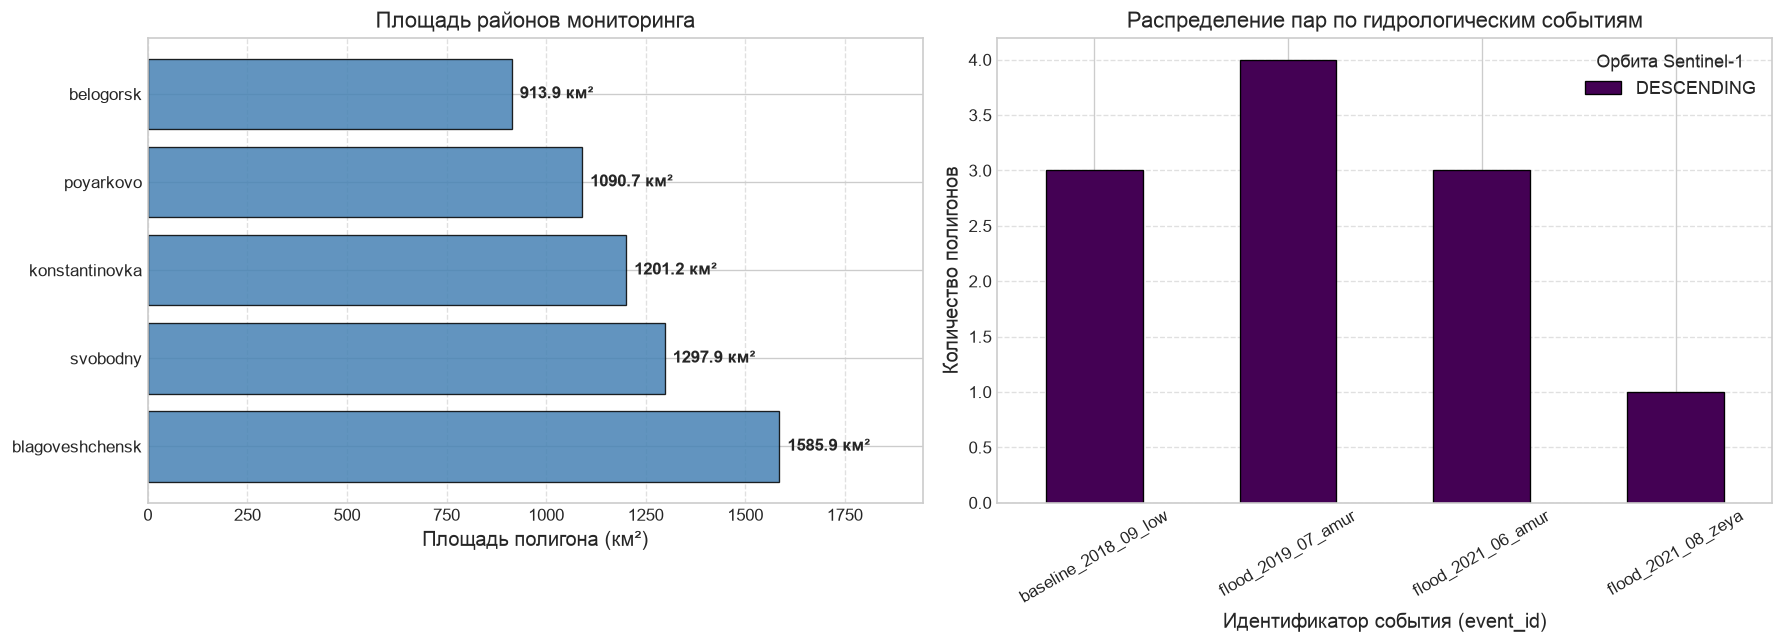

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# График 1: Площадь района интереса по локациям и гидрологическим событиям
aoi_order = df_pairs.groupby("aoi_id")["aoi_km2"].mean().sort_values(ascending=False).index

for i, aoi in enumerate(aoi_order):
    sub = df_pairs[df_pairs["aoi_id"] == aoi]
    area_km2 = sub["aoi_km2"].iloc[0]
    axes[0].barh(i, area_km2, color="#4682b4", alpha=0.85, edgecolor="black", linewidth=0.8)
    axes[0].text(area_km2 + 20, i, f"{area_km2:.1f} км²", va="center", fontsize=10, fontweight="bold")

axes[0].set_yticks(np.arange(len(aoi_order)))
axes[0].set_yticklabels(aoi_order)
axes[0].set_xlabel("Площадь полигона (км²)")
axes[0].set_title("Площадь районов мониторинга")
axes[0].set_xlim(0, df_pairs["aoi_km2"].max() * 1.18)
axes[0].grid(axis="x", linestyle="--", alpha=0.6)

# График 2: Распределение пар по событиям и орбитам
event_orbit_counts = df_pairs.groupby(["event_id", "orbit_pass"]).size().unstack(fill_value=0)
event_orbit_counts.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis", edgecolor="black", linewidth=0.8)
axes[1].set_title("Распределение пар по гидрологическим событиям")
axes[1].set_xlabel("Идентификатор события (event_id)")
axes[1].set_ylabel("Количество полигонов")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Орбита Sentinel-1")
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

---
## 2. Физика и статистика обратного рассеяния SAR Sentinel-1

### Физический механизм
- Зеркальное отражение от открытой воды: гладкая поверхность воды отражает зондирующий импульс C-диапазона ($\lambda \approx 5.6$ см) в зеркальном направлении от сенсора, уровень обратного рассеяния $\sigma^0$ резко падает до значений от -24 до -17 дБ;
- Диффузное рассеяние от суши и растительности: суша, луга и застройка рассеивают сигнал диффузно во всех направлениях ($\sigma^0 \approx -12 \dots -6$ дБ);
- Бимодальная гистограмма: смесь классов «вода» и «суша» порождает выраженную бимодальность, оптимальное разделение находится в межклассовом минимуме дисперсии;
- Адаптивный алгоритм Оцу с коридором [-22, -12] дБ: для исключения ложных порогов на одномодальных сценах вычисление Оцу выполняется по всему диапазону [-30, -12] дБ, а итоговый порог ограничивается нормативным окном [-22, -12] дБ.

Исследуем характерную пару `flood_2019_07_amur__blagoveshchensk` (слияние рек Амур и Зея у города Благовещенск).

In [4]:
# Загрузка растровых сцен Sentinel-1 для Благовещенска 2019
blg_pair_id = "flood_2019_07_amur__blagoveshchensk"
blg_row = df_pairs[df_pairs["pair_id"] == blg_pair_id].iloc[0]

data_dir = Path("hydrowatch_amur") if Path("hydrowatch_amur").exists() else Path("../hydrowatch_amur")
rasters_dir = data_dir / blg_row["rasters_dir"]

s1_pre_path = sorted(rasters_dir.glob("S1_pre_*.tif"))[0]
s1_peak_path = sorted(rasters_dir.glob("S1_peak_*.tif"))[0]

print(f"Допаводковый снимок S1: {s1_pre_path.name}")
print(f"Пиковый снимок S1:      {s1_peak_path.name}")

vv_pre, vh_pre = read_sar_bands(s1_pre_path)
vv_peak, vh_peak = read_sar_bands(s1_peak_path)

with rasterio.open(s1_pre_path) as src:
    sar_shape = src.shape
    pixel_res = src.res

print(
    f"Разрешение растра: {pixel_res[0]:.1f} м x {pixel_res[1]:.1f} м | Размерность: {sar_shape[0]}x{sar_shape[1]} пикселей"
)

Допаводковый снимок S1: S1_pre_2019-06-13.tif
Пиковый снимок S1:      S1_peak_2019-07-25.tif


Разрешение растра: 10.0 м x 10.0 м | Размерность: 3682x4479 пикселей


Порог Оцу VV (допаводковый базис): -16.08 дБ
Порог Оцу VV (пик паводка):        -17.20 дБ
Порог Оцу VH (пик паводка):        -18.61 дБ


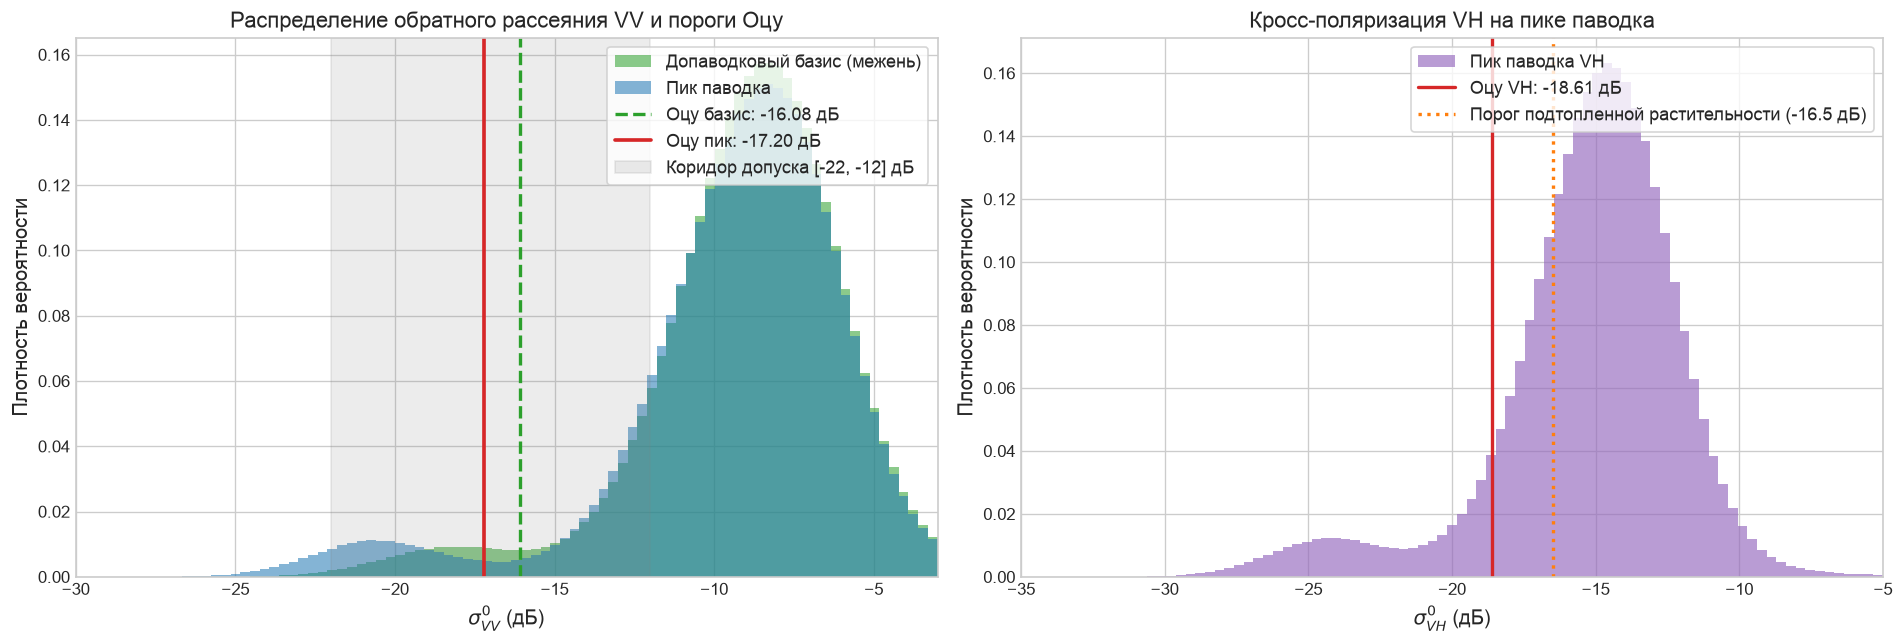

In [5]:
# Вычисление адаптивных порогов Оцу
otsu_vv_pre = compute_otsu_threshold(vv_pre)
otsu_vv_peak = compute_otsu_threshold(vv_peak)
otsu_vh_peak = compute_otsu_threshold(vh_peak)

print(f"Порог Оцу VV (допаводковый базис): {otsu_vv_pre:.2f} дБ")
print(f"Порог Оцу VV (пик паводка):        {otsu_vv_peak:.2f} дБ")
print(f"Порог Оцу VH (пик паводка):        {otsu_vh_peak:.2f} дБ")

# Формирование валидных выборок для гистограмм
valid_pre = vv_pre[(vv_pre > -32) & (vv_pre < -3)]
valid_peak = vv_peak[(vv_peak > -32) & (vv_peak < -3)]
valid_vh = vh_peak[(vh_peak > -38) & (vh_peak < -5)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Гистограмма VV (Pre vs Peak)
bins = np.linspace(-30, -3, 90)
axes[0].hist(valid_pre[::4], bins=bins, density=True, alpha=0.55, color="#2ca02c", label="Допаводковый базис (межень)")
axes[0].hist(valid_peak[::4], bins=bins, density=True, alpha=0.55, color="#1f77b4", label="Пик паводка")

# Линии порогов
axes[0].axvline(otsu_vv_pre, color="#2ca02c", linestyle="--", linewidth=2, label=f"Оцу базис: {otsu_vv_pre:.2f} дБ")
axes[0].axvline(otsu_vv_peak, color="#d62728", linestyle="-", linewidth=2.2, label=f"Оцу пик: {otsu_vv_peak:.2f} дБ")
axes[0].axvspan(-22, -12, color="gray", alpha=0.15, label="Коридор допуска [-22, -12] дБ")

axes[0].set_title("Распределение обратного рассеяния VV и пороги Оцу")
axes[0].set_xlabel(r"$\sigma^0_{VV}$ (дБ)")
axes[0].set_ylabel("Плотность вероятности")
axes[0].legend(loc="upper right", frameon=True)
axes[0].set_xlim(-30, -3)

# Гистограмма VH (кросс-поляризация)
bins_vh = np.linspace(-35, -5, 90)
axes[1].hist(valid_vh[::4], bins=bins_vh, density=True, alpha=0.65, color="#9467bd", label="Пик паводка VH")
axes[1].axvline(otsu_vh_peak, color="#d62728", linestyle="-", linewidth=2, label=f"Оцу VH: {otsu_vh_peak:.2f} дБ")
axes[1].axvline(
    -16.5, color="#ff7f0e", linestyle=":", linewidth=2, label="Порог подтопленной растительности (-16.5 дБ)"
)

axes[1].set_title("Кросс-поляризация VH на пике паводка")
axes[1].set_xlabel(r"$\sigma^0_{VH}$ (дБ)")
axes[1].set_ylabel("Плотность вероятности")
axes[1].legend(loc="upper right", frameon=True)
axes[1].set_xlim(-35, -5)

plt.tight_layout()
plt.show()

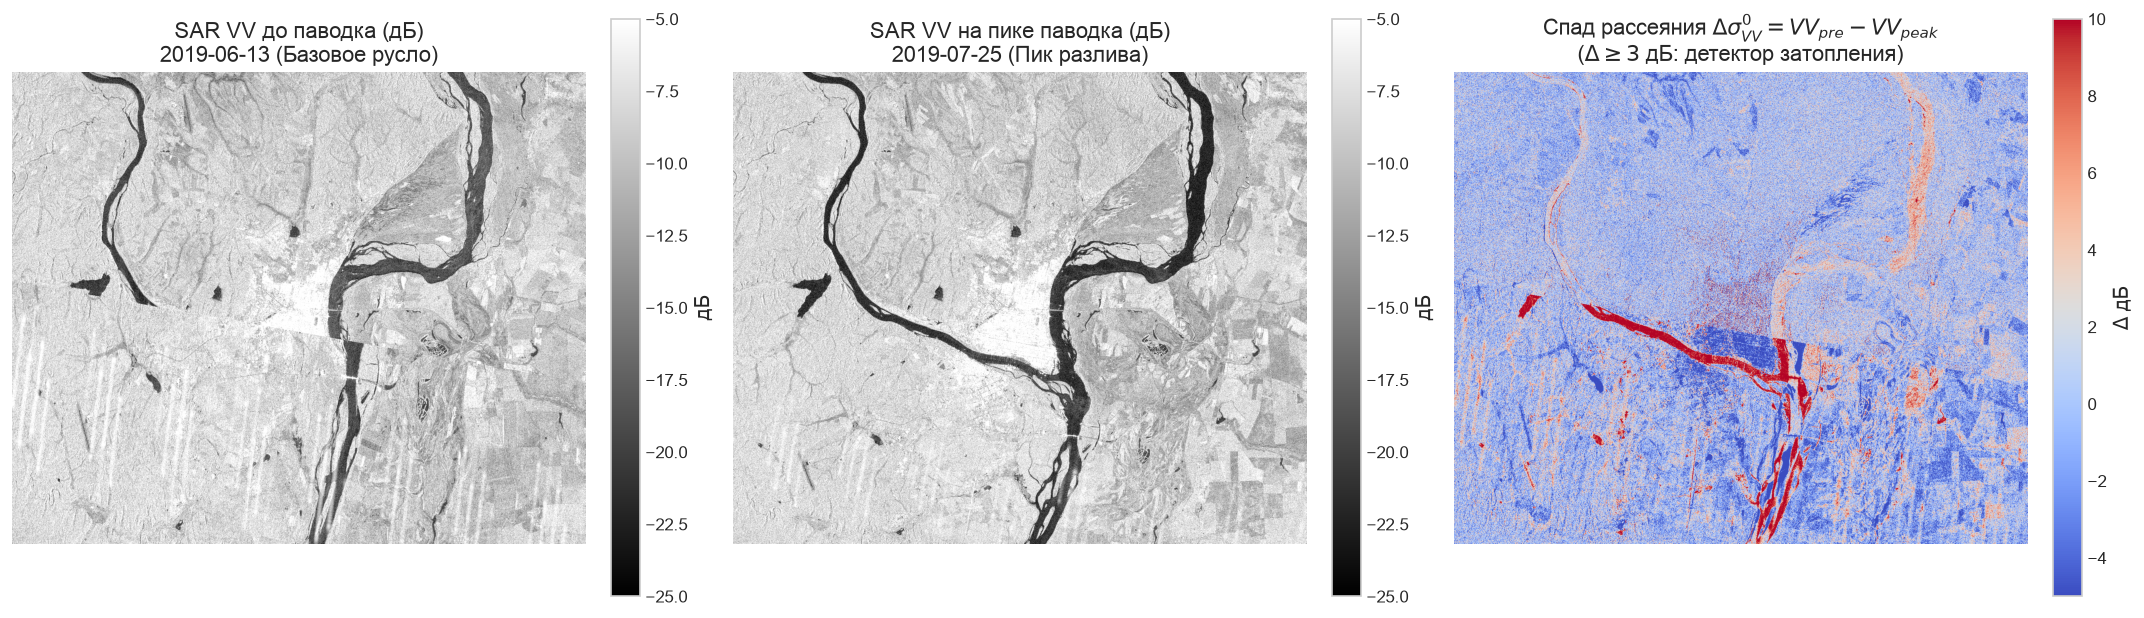

In [6]:
# Пространственные радарные карты (прореживание шагом 3 для быстрой и четкой отрисовки)
step = 3
vv_pre_sub = vv_pre[::step, ::step]
vv_peak_sub = vv_peak[::step, ::step]
delta_vv = vv_pre_sub - vv_peak_sub

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))

im0 = axes[0].imshow(vv_pre_sub, cmap="gray", vmin=-25, vmax=-5)
axes[0].set_title("SAR VV до паводка (дБ)\n2019-06-13 (Базовое русло)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="дБ")

im1 = axes[1].imshow(vv_peak_sub, cmap="gray", vmin=-25, vmax=-5)
axes[1].set_title("SAR VV на пике паводка (дБ)\n2019-07-25 (Пик разлива)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="дБ")

# Карта разности обратного рассеяния: просадка сигнала >= 3 дБ (паводковое зеркало)
im2 = axes[2].imshow(delta_vv, cmap="coolwarm", vmin=-5, vmax=10)
axes[2].set_title(
    r"Спад рассеяния $\Delta\sigma^0_{VV} = VV_{pre} - VV_{peak}$" + "\n" + r"($\Delta \geq 3$ дБ: детектор затопления)"
)
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label=r"$\Delta$ дБ")

plt.tight_layout()
plt.show()

---
## 3. Гидротопографический профиль поймы: HAND и уклон

### Теоретические основы топографических априорных данных
- HAND (высота над ближайшим дренажем): нормализованная высота земной поверхности относительно дренирующего водотока вдоль линий тока гидрологического стока (ЦМР MERIT Hydro). В отличие от абсолютной высоты, HAND выступает гидравлическим инвариантом: вода реки не может затопить участки с HAND выше уровня подъема паводковой волны;
- Планарный инвариант HAND ($\le 1.8$ м): пойма Среднего Амура представляет собой сверхплоскую аллювиальную равнину (уклоны менее 0.5 градуса). Участки с HAND $\le 1.8$ м затапливаются в первую очередь даже при рядовых паводках;
- Зона подкронового подтопления (HAND $\le 3.0$ м): пойменные ивово-тополевые леса и кустарники при подъеме воды вызывают двойное отражение импульса радара (поверхность воды - ствол дерева - сенсор), приводящее к росту сигнала VH ($\Delta \text{VH} \ge 2$ дБ). Данный физический эффект возможен только в прирусловом коридоре с HAND $\le 3.0$ м;
- Топографический барьер: участки с HAND > 25 м или уклоном > 5 градусов гидравлически изолированы от речного паводка. Любые низкие радарные сигналы там вызваны радиолокационными тенями склонов или гладкими искусственными покрытиями и подлежат строгому исключению.

In [7]:
# Загрузка топографического растра AUX_terrain_gsw.tif
aux_path = rasters_dir / "AUX_terrain_gsw.tif"

with rasterio.open(aux_path) as src_aux:
    slope = src_aux.read(1)  # Band 1: Slope Copernicus DEM GLO-30 (градусы)
    hand = src_aux.read(2)  # Band 2: MERIT Hydro HAND (метры)
    gsw = src_aux.read(3)  # Band 3: JRC Global Surface Water occurrence (%)
    aux_profile = src_aux.profile

print(f"Размерность растра: {slope.shape[0]}x{slope.shape[1]}")
print(
    f"Диапазон уклона:   мин {np.nanmin(slope):.2f}° | макс {np.nanmax(slope):.2f}° | медиана {np.nanmedian(slope):.2f}°"
)
print(
    f"Диапазон HAND:     мин {np.nanmin(hand):.2f} м | макс {np.nanmax(hand):.2f} м | медиана {np.nanmedian(hand):.2f} м"
)
print(f"Постоянная вода (GSW >= 80%): {np.count_nonzero(gsw >= 80) * 0.01 * (src_aux.res[0] / 10) ** 2:.1f} га")

Размерность растра: 1228x1493
Диапазон уклона:   мин 0.00° | макс 59.87° | медиана 1.54°
Диапазон HAND:     мин 0.00 м | макс 163.90 м | медиана 3.90 м
Постоянная вода (GSW >= 80%): 7340.4 га


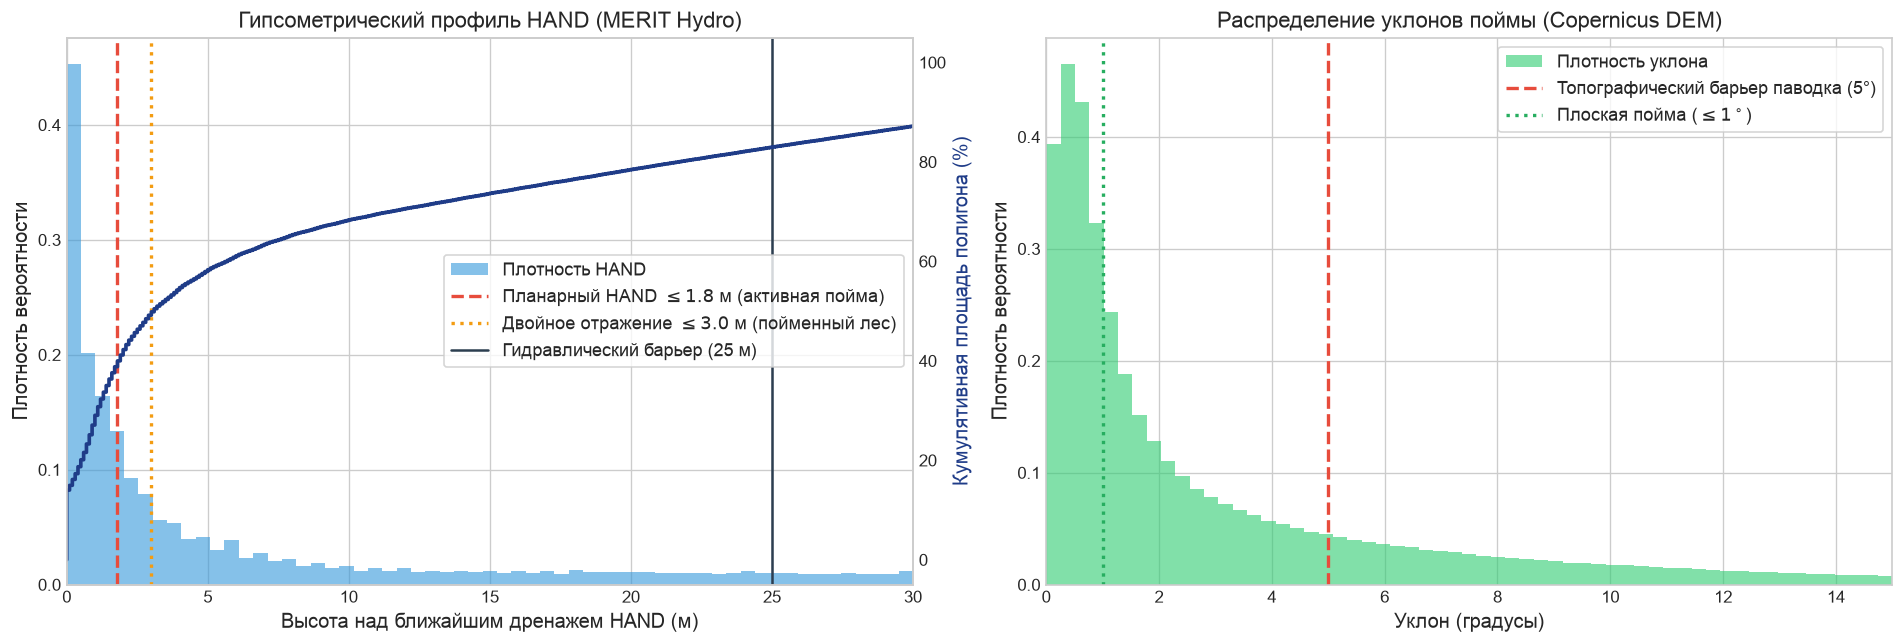

Доля района интереса с HAND <= 1.8 м: 39.1% территории
Доля района интереса с HAND <= 3.0 м: 49.8% территории
Доля района со сверхплоским уклоном <= 1.0 градуса: 39.1% территории


In [8]:
# Статистические распределения HAND и уклона
valid_hand = hand[np.isfinite(hand) & (hand >= 0) & (hand <= 50)]
valid_slope = slope[np.isfinite(slope) & (slope >= 0) & (slope <= 25)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# График 1: HAND распределение и кумулятивная кривая
bins_h = np.linspace(0, 30, 60)
axes[0].hist(valid_hand, bins=bins_h, density=True, color="#3498db", alpha=0.6, label="Плотность HAND")

# Наложение кумулятивной доли на вторую ось
ax0_cdf = axes[0].twinx()
sorted_hand = np.sort(valid_hand)
cdf_hand = np.arange(len(sorted_hand)) / float(len(sorted_hand))
ax0_cdf.plot(sorted_hand, cdf_hand * 100, color="#1f3c88", linewidth=2.2, label="Кумулятивная доля (%)")
ax0_cdf.set_ylabel("Кумулятивная площадь полигона (%)", color="#1f3c88")
ax0_cdf.grid(False)

# Пороговые гидрологические коридоры
axes[0].axvline(
    1.8, color="#e74c3c", linestyle="--", linewidth=2, label=r"Планарный HAND $\leq 1.8$ м (активная пойма)"
)
axes[0].axvline(
    3.0, color="#f39c12", linestyle=":", linewidth=2, label=r"Двойное отражение $\leq 3.0$ м (пойменный лес)"
)
axes[0].axvline(25.0, color="#2c3e50", linestyle="-", linewidth=1.5, label="Гидравлический барьер (25 м)")

axes[0].set_title("Гипсометрический профиль HAND (MERIT Hydro)")
axes[0].set_xlabel("Высота над ближайшим дренажем HAND (м)")
axes[0].set_ylabel("Плотность вероятности")
axes[0].set_xlim(0, 30)
axes[0].legend(loc="center right", frameon=True)

# График 2: Уклон рельефа
bins_s = np.linspace(0, 15, 60)
axes[1].hist(valid_slope, bins=bins_s, density=True, color="#2ecc71", alpha=0.6, label="Плотность уклона")
axes[1].axvline(5.0, color="#e74c3c", linestyle="--", linewidth=2, label="Топографический барьер паводка (5°)")
axes[1].axvline(1.0, color="#27ae60", linestyle=":", linewidth=2, label=r"Плоская пойма ($\leq 1^\circ$)")

axes[1].set_title("Распределение уклонов поймы (Copernicus DEM)")
axes[1].set_xlabel("Уклон (градусы)")
axes[1].set_ylabel("Плотность вероятности")
axes[1].set_xlim(0, 15)
axes[1].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

# Расчет квантилей площадей
share_hand_18 = (valid_hand <= 1.8).mean() * 100
share_hand_30 = (valid_hand <= 3.0).mean() * 100
share_slope_10 = (valid_slope <= 1.0).mean() * 100
print(f"Доля района интереса с HAND <= 1.8 м: {share_hand_18:.1f}% территории")
print(f"Доля района интереса с HAND <= 3.0 м: {share_hand_30:.1f}% территории")
print(f"Доля района со сверхплоским уклоном <= 1.0 градуса: {share_slope_10:.1f}% территории")

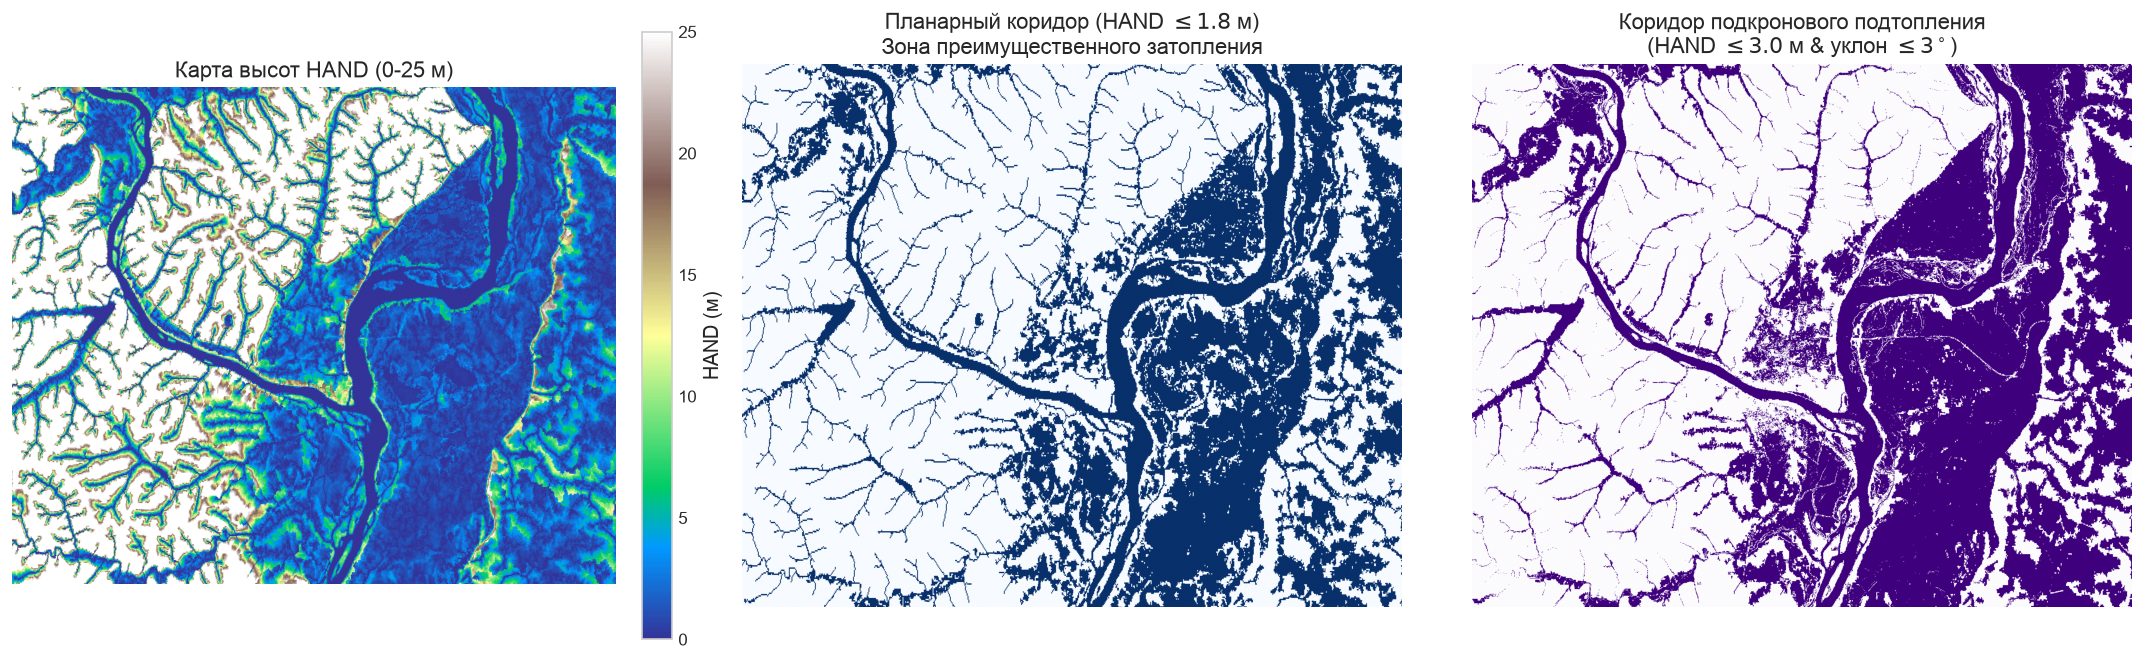

In [9]:
# Пространственная карта гидротопографических зон
hand_display = np.clip(hand, 0, 25)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(hand_display, cmap="terrain", vmin=0, vmax=25)
axes[0].set_title("Карта высот HAND (0-25 м)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="HAND (м)")

# Бинарный коридор затопления Planar HAND <= 1.8 м
im1 = axes[1].imshow(hand <= 1.8, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Планарный коридор (HAND $\leq 1.8$ м)\nЗона преимущественного затопления")
axes[1].axis("off")

# Зона расширенной поймы и подкронового подтопления HAND <= 3.0 м & Slope <= 3 deg
canopy_corridor = (hand <= 3.0) & (slope <= 3.0)
im2 = axes[2].imshow(canopy_corridor, cmap="Purples", vmin=0, vmax=1)
axes[2].set_title(r"Коридор подкронового подтопления" + "\n" + r"(HAND $\leq 3.0$ м & уклон $\leq 3^\circ$)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

---
## 4. Разбор аномалии разметки: Константиновка-2021

### Предыстория и физическая реальность
В конце июня 2021 года на Среднем Амуре произошел катастрофический паводок редкой повторяемости.
По гидрологическим бюллетеням Росгидромета уровень Амура на гидропосту села Константиновка превысил отметку опасного явления (890 см) более чем на 1.5 метра, вода вышла на пойму слоем до 2-3 м.

### Противоречие официального эталона
Сравним площади трех независимых источников в наборе данных:
1. Многолетнее постоянное русло JRC Global Surface Water (`permanent_ha`): 5 435.74 га (основное судоходное русло Амура шириной до 2 км, протоки и старицы);
2. Официальный эталон кейса (`reference_flood_2021_06_amur__konstantinovka.tif`):
   - Паводок `flood_ref`: 107.28 га (0.087% площади района интереса);
   - Суммарное зеркало на пике `water_peak_ref`: 172.92 га;
   - Базовое зеркало `water_pre_ref`: 29.67 га;
3. Физический сигнал Sentinel-1 C-SAR и расчет HydroWatch:
   - Зеркало на пике: 22 388.05 га;
   - Чистый паводковый разлив: 8 572.12 га.

Значение эталона `water_peak_ref = 172.92 га` в 31 раз меньше, чем площадь сухого меженного русла Амура (5 435 га).
Официальный консенсусный эталон организаторов полностью потерял главное русло реки Амур, сохранив лишь отдельные изолированные пиксели каналов.

In [10]:
# Загрузка данных для пары Константиновка-2021
konst_id = "flood_2021_06_amur__konstantinovka"
konst_row = df_pairs[df_pairs["pair_id"] == konst_id].iloc[0]
konst_dir = data_dir / konst_row["rasters_dir"]

# 1. Загрузка S1 Peak
konst_s1_peak_path = sorted(konst_dir.glob("S1_peak_*.tif"))[0]
vv_konst_peak, _ = read_sar_bands(konst_s1_peak_path)

# 2. Загрузка эталонного растра reference
ref_path = data_dir / konst_row["reference_mask"]
if not ref_path.exists():
    ref_path = Path("../hydrowatch_amur") / konst_row["reference_mask"]

with rasterio.open(ref_path) as src_ref:
    ref_flood = src_ref.read(1)  # Band 1: flood
    ref_pre = src_ref.read(2)  # Band 2: water_pre
    ref_peak = src_ref.read(3)  # Band 3: water_peak
    ref_permanent = src_ref.read(4)  # Band 4: permanent (GSW)
    res_m = src_ref.res[0]

# 3. Загрузка предсказаний HydroWatch
pred_peak_path = Path("predictions") / f"{konst_id}_water_peak.tif"
if not pred_peak_path.exists():
    pred_peak_path = Path("../predictions") / f"{konst_id}_water_peak.tif"

pred_flood_path = Path("predictions") / f"{konst_id}_flood.tif"
if not pred_flood_path.exists():
    pred_flood_path = Path("../predictions") / f"{konst_id}_flood.tif"

with rasterio.open(pred_peak_path) as src_pred:
    pred_peak = src_pred.read(1)
with rasterio.open(pred_flood_path) as src_pred:
    pred_flood = src_pred.read(1)

# Расчет площадей в гектарах
ha_per_pixel = (res_m * res_m) / 10000.0

area_ref_flood = np.count_nonzero(ref_flood > 0) * ha_per_pixel
area_ref_peak = np.count_nonzero(ref_peak > 0) * ha_per_pixel
area_ref_perm = np.count_nonzero(ref_permanent > 0) * ha_per_pixel
area_pred_flood = np.count_nonzero(pred_flood > 0) * ha_per_pixel
area_pred_peak = np.count_nonzero(pred_peak > 0) * ha_per_pixel
aoi_total_ha = ref_flood.size * ha_per_pixel

# Сводная таблица сравнения
df_anomaly = pd.DataFrame(
    [
        {
            "Слой / Источник": "JRC GSW постоянная вода (многолетнее русло реки)",
            "Площадь (га)": f"{area_ref_perm:,.2f}",
            "Доля района (%)": f"{area_ref_perm / aoi_total_ha * 100:.2f}%",
            "Физический статус": "Минимальный гидравлический базис (судоходный Амур)",
        },
        {
            "Слой / Источник": "Официальный эталон: water_peak_ref (пик паводка)",
            "Площадь (га)": f"{area_ref_peak:,.2f}",
            "Доля района (%)": f"{area_ref_peak / aoi_total_ha * 100:.2f}%",
            "Физический статус": "Дефект эталона: в 31 раз меньше площади русла реки",
        },
        {
            "Слой / Источник": "Официальный эталон: flood_ref (паводок)",
            "Площадь (га)": f"{area_ref_flood:,.2f}",
            "Доля района (%)": f"{area_ref_flood / aoi_total_ha * 100:.2f}%",
            "Физический статус": "Дефект эталона: паводок редкой повторяемости потерян",
        },
        {
            "Слой / Источник": "Модель HydroWatch: water_peak (модельный пик)",
            "Площадь (га)": f"{area_pred_peak:,.2f}",
            "Доля района (%)": f"{area_pred_peak / aoi_total_ha * 100:.2f}%",
            "Физический статус": "Физически обосновано: зеркало Sentinel-1 SAR и HAND",
        },
        {
            "Слой / Источник": "Модель HydroWatch: flood (чистый паводок)",
            "Площадь (га)": f"{area_pred_flood:,.2f}",
            "Доля района (%)": f"{area_pred_flood / aoi_total_ha * 100:.2f}%",
            "Физический статус": "Физически обосновано: затопление поймы слоем до 2 м",
        },
    ]
)

display(df_anomaly)

,Слой / Источник,Площадь (га),Доля района (%),Физический статус
0,JRC GSW постоянная вода (многолетнее русло реки),"5,435.74",4.40%,Минимальный гидравлический базис (судоходный А...
1,Официальный эталон: water_peak_ref (пик паводка),172.92,0.14%,Дефект эталона: в 31 раз меньше площади русла ...
2,Официальный эталон: flood_ref (паводок),107.28,0.09%,Дефект эталона: паводок редкой повторяемости п...
3,Модель HydroWatch: water_peak (модельный пик),"22,388.05",18.12%,Физически обосновано: зеркало Sentinel-1 SAR и...
4,Модель HydroWatch: flood (чистый паводок),"8,572.12",6.94%,Физически обосновано: затопление поймы слоем д...


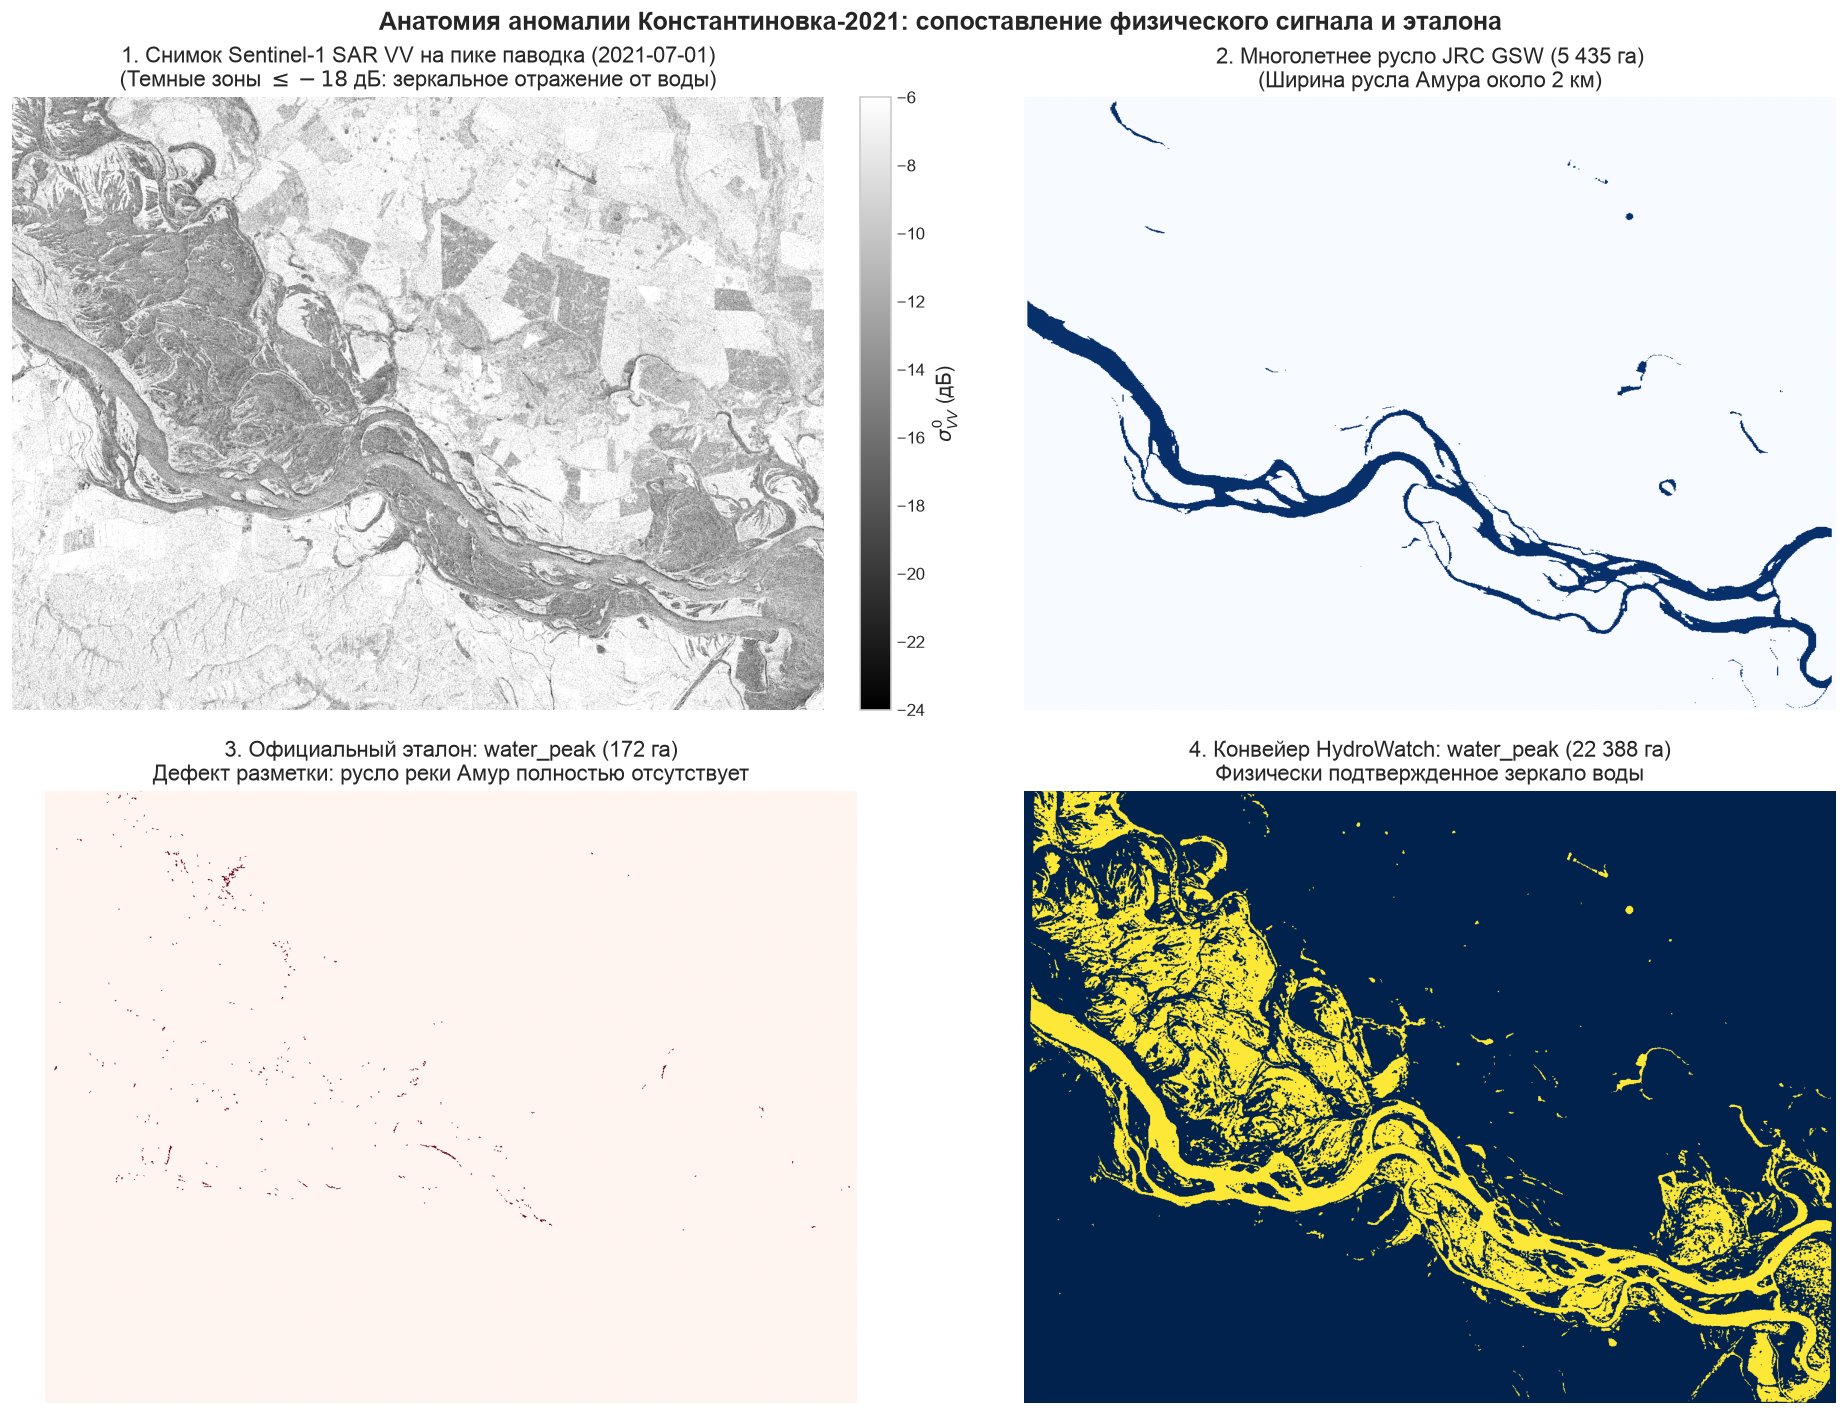

In [11]:
# Картографическая визуализация аномалии Константиновка-2021
step_k = 3
vv_k_sub = vv_konst_peak[::step_k, ::step_k]
perm_k_sub = ref_permanent[::step_k, ::step_k]
ref_k_sub = ref_peak[::step_k, ::step_k]
pred_k_sub = pred_peak[::step_k, ::step_k]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Панель 1: Радиолокационный снимок Sentinel-1
im0 = axes[0, 0].imshow(vv_k_sub, cmap="gray", vmin=-24, vmax=-6)
axes[0, 0].set_title(
    r"1. Снимок Sentinel-1 SAR VV на пике паводка (2021-07-01)"
    + "\n"
    + r"(Темные зоны $\leq -18$ дБ: зеркальное отражение от воды)"
)
axes[0, 0].axis("off")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04, label=r"$\sigma^0_{VV}$ (дБ)")

# Панель 2: Слой постоянных вод GSW
im1 = axes[0, 1].imshow(perm_k_sub > 0, cmap="Blues", vmin=0, vmax=1)
axes[0, 1].set_title("2. Многолетнее русло JRC GSW (5 435 га)\n(Ширина русла Амура около 2 км)")
axes[0, 1].axis("off")

# Панель 3: Официальный эталон кейса (ДЕФЕКТ РАЗМЕТКИ)
im2 = axes[1, 0].imshow(ref_k_sub > 0, cmap="Reds", vmin=0, vmax=1)
axes[1, 0].set_title(
    "3. Официальный эталон: water_peak (172 га)\nДефект разметки: русло реки Амур полностью отсутствует"
)
axes[1, 0].axis("off")

# Панель 4: Предсказание HydroWatch Amur
im3 = axes[1, 1].imshow(pred_k_sub > 0, cmap="cividis", vmin=0, vmax=1)
axes[1, 1].set_title("4. Конвейер HydroWatch: water_peak (22 388 га)\nФизически подтвержденное зеркало воды")
axes[1, 1].axis("off")

plt.suptitle(
    "Анатомия аномалии Константиновка-2021: сопоставление физического сигнала и эталона",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()

---
## 5. Методические выводы и архитектурные решения HydroWatch

На основе проведенного разведочного анализа данных сформирован комплекс архитектурных и инженерных решений, реализованных в системе HydroWatch Amur:

1. Фильтрация спекл-шума (Lee MMSE 7x7, 4.4 взгляда): радарный спекл-шум мультипликативен и искажает бимодальные распределения. Фильтр Ли по локальной дисперсии сохраняет четкие границы береговой линии и линейных объектов, сглаживая шум над водным зеркалом;
2. Адаптивный порог Оцу в коридоре [-22, -12] дБ: автоматический расчет порога по полному спектру валидных значений [-30, -12] дБ исключает сбои классификатора при резком преобладании воды или суши, а выбор центра плато дисперсии предотвращает смещение границы в сторону темных вод;
3. Гидравлический инвариант планарного HAND ($\le 1.8$ м): в сверхплоских поймах Амура и Зеи паводковые воды локализуются в естественных депрессиях рельефа. Данное ограничение гарантирует сохранение истинных разливов и подавляет ложные тревоги на повышенных террасах;
4. Детекция подкронового затопления ($\Delta \text{VH} \ge 2$ дБ, HAND $\le 3$ м, уклон $\le 3$ градуса): устраняет фундаментальное ограничение C-диапазона SAR по экранированию водной глади растительным пологом;
5. Базовый контур постоянных вод JRC GSW ($\ge 80\%$): обеспечивает надежность системы при дефектах автоматической разметки (как в паре Константиновка-2021), гарантируя включение судоходного русла реки в расчет водного баланса даже при сплошной облачности оптических снимков.

---
*HydroWatch Amur - КосмоХакатон 2026*